# Week 02 Assignment

## End-to-End Machine Learning Pipeline on Tesla Deliveries Dataset

### Objective

Develop an end-to-end machine learning pipeline to analyze and predict Tesla deliveries using data preprocessing, exploratory data analysis (EDA), feature engineering, regression modeling, hyperparameter tuning, stationarity testing, and forecasting.

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from statsmodels.tsa.stattools import adfuller

### 2. Load and Explore the Dataset

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

In [3]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


### 3. Dataset Overview

In [4]:
print("Shape of the dataset:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Shape of the dataset: (2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [6]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


### 4. Data Quality Check
Check the dataset for missing values and duplicate records to ensure data quality.

In [7]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values in each column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Number of duplicate rows: 0


**Observation:**

- No missing values were found in the dataset.
- No duplicate records were detected.
- The dataset is clean and ready for exploratory data analysis (EDA).

### 5. Exploratory Data Analysis (EDA)

Visualize the dataset to understand the distribution of deliveries and relationships between different features.

#### 5.1 Average Estimated Deliveries by Tesla Model

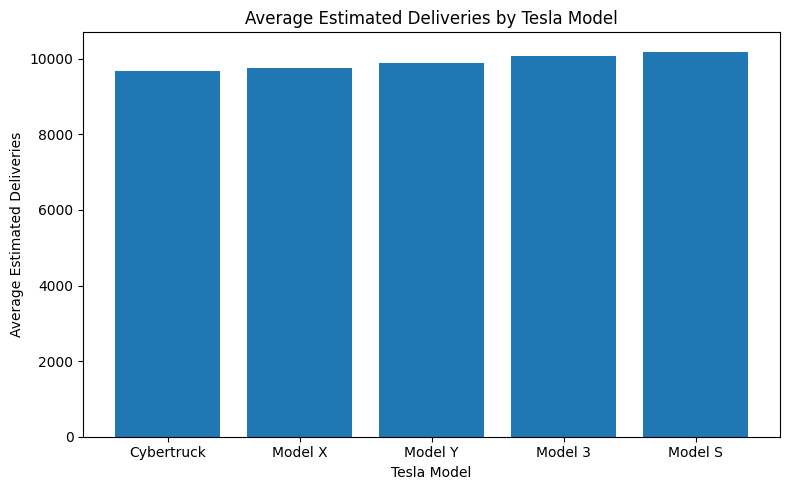

In [8]:
# Calculate average estimated deliveries for each Tesla model
model_deliveries = df.groupby("Model")["Estimated_Deliveries"].mean().sort_values()

plt.figure(figsize=(8, 5))
plt.bar(model_deliveries.index, model_deliveries.values)

plt.title("Average Estimated Deliveries by Tesla Model")
plt.xlabel("Tesla Model")
plt.ylabel("Average Estimated Deliveries")

plt.tight_layout()
plt.show()

**Observation:**

The average estimated deliveries are fairly similar across all Tesla models, with Model S showing a slightly higher average and Cybertruck the lowest among the displayed models.

#### 5.2 Average Estimated Deliveries by Region

This chart compares the average estimated deliveries across different geographical regions.

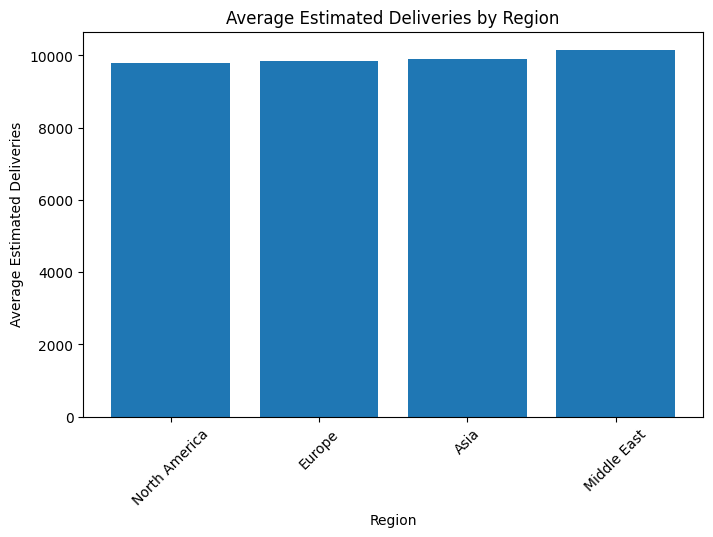

In [9]:
# Calculate average estimated deliveries for each region
region_delivery = df.groupby("Region")["Estimated_Deliveries"].mean().sort_values()

plt.figure(figsize=(8,5))

# Create a bar chart
plt.bar(region_delivery.index, region_delivery.values)

plt.title("Average Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Average Estimated Deliveries")
plt.xticks(rotation=45)

plt.show()

**Observation:**

* The average estimated deliveries are nearly similar across all regions.
* Middle East has the highest average estimated deliveries.
* North America has the lowest average estimated deliveries.
* Overall, the variation in average estimated deliveries across regions is small.

#### 5.3 Estimated Deliveries Trend Over the Years

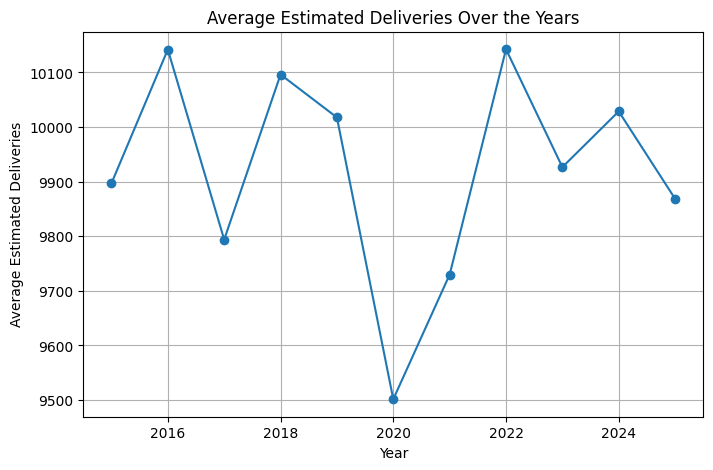

In [10]:
# Calculate the average estimated deliveries for each year
yearly_delivery = df.groupby("Year")["Estimated_Deliveries"].mean()

# Plot the yearly delivery trend
plt.figure(figsize=(8,5))
plt.plot(yearly_delivery.index,
         yearly_delivery.values,
         marker='o')

plt.title("Average Estimated Deliveries Over the Years")
plt.xlabel("Year")
plt.ylabel("Average Estimated Deliveries")

plt.grid(True)
plt.show()

**Observation:**

* The average estimated deliveries fluctuate slightly over the years.
* The lowest average estimated deliveries are observed in **2020**.
* The highest average estimated deliveries are observed around **2016** and **2022**.
* Overall, the average estimated deliveries remain relatively stable over the years without a strong increasing or decreasing trend.


#### 5.4 Correlation Heatmap

Visualize the correlation between numerical features to identify relationships and understand how different variables are associated with each other.

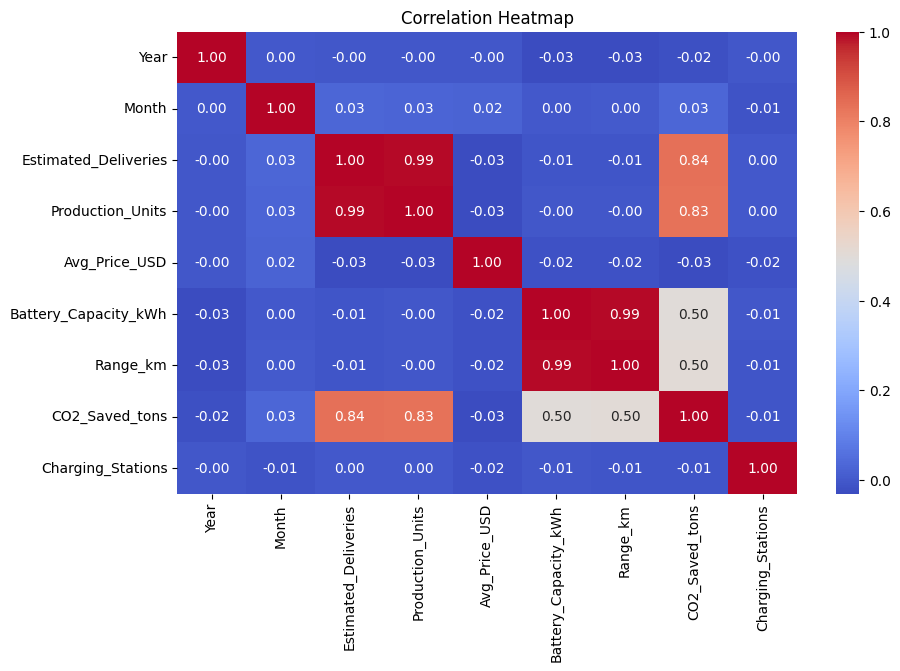

In [11]:
# Calculate the correlation between numerical features
correlation_matrix = df.corr(numeric_only=True)

# Create the heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(correlation_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

**Observation:**

* Estimated Deliveries and Production Units have a very strong positive correlation (0.99).
* Battery Capacity and Range are also highly positively correlated (0.99).
* CO2 Saved shows a strong positive relationship with both Estimated Deliveries and Production Units.
* Most other numerical features have weak or no significant correlation with each other.

#### 5.5 Production Units vs Estimated Deliveries

Visualize the relationship between production units and estimated deliveries to understand whether higher production leads to higher deliveries.

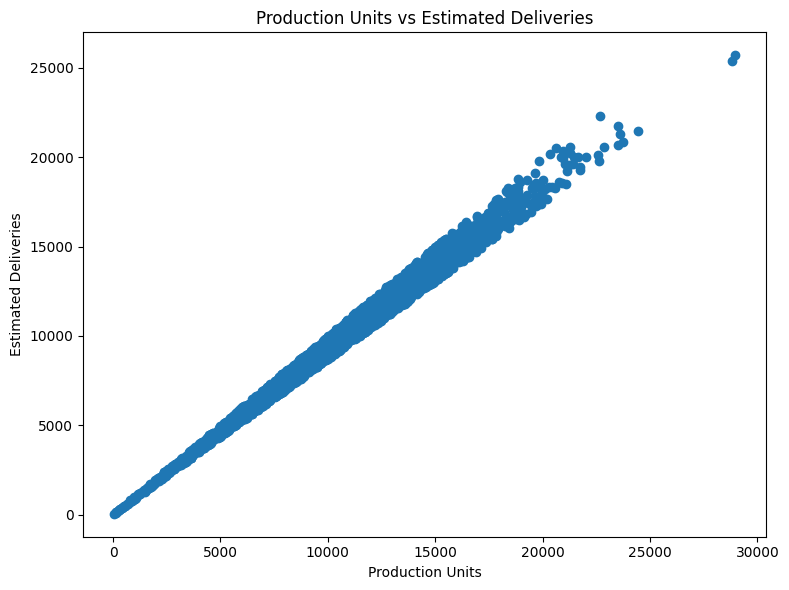

In [12]:
# Create a scatter plot to show the relationship between production units and estimated deliveries
plt.figure(figsize=(8, 6))

plt.scatter(df['Production_Units'],
            df['Estimated_Deliveries'])

plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.tight_layout()
plt.show()

**Observation:**

* Production Units and Estimated Deliveries show a strong positive relationship.
* As production units increase, estimated deliveries also increase.
* Most data points are closely clustered, indicating a strong correlation between the two variables.
* The scatter plot supports the strong positive correlation observed in the correlation heatmap.

### 6. Feature Encoding

Encode the categorical features using LabelEncoder so they can be used for machine learning models.

In [13]:
# Create a LabelEncoder object
le = LabelEncoder()

# Encode categorical columns
df['Region'] = le.fit_transform(df['Region'])
df['Model'] = le.fit_transform(df['Model'])
df['Source_Type'] = le.fit_transform(df['Source_Type'])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


### 7. Feature Engineering

#### 7.1 Create Lag Feature

Create a lag feature using the previous delivery value and replace the resulting missing value with the column mean.

In [14]:
# Create a lag feature using previous delivery values
df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)
df['Deliveries_Lag1'] = df['Deliveries_Lag1'].fillna(df['Deliveries_Lag1'].mean())
df[['Estimated_Deliveries', 'Deliveries_Lag1']].head()

,Estimated_Deliveries,Deliveries_Lag1
0,17646,9924.959454
1,3797,17646.000000
2,8411,3797.000000
3,6555,8411.000000
4,12374,6555.000000


#### 7.2 Create Rolling Mean Feature

Create a 3-period rolling mean of estimated deliveries and replace the resulting missing values with the column mean.

In [15]:
# Create a 3-period rolling mean feature
df['Rolling_Mean_3'] = df['Estimated_Deliveries'].rolling(window=3).mean()
df['Rolling_Mean_3'] = df['Rolling_Mean_3'].fillna(df['Rolling_Mean_3'].mean())
df[['Estimated_Deliveries', 'Rolling_Mean_3']].head()

,Estimated_Deliveries,Rolling_Mean_3
0,17646,9923.677407
1,3797,9923.677407
2,8411,9951.333333
3,6555,6254.333333
4,12374,9113.333333


### 8. Train-Test Split

Split the dataset chronologically into training (80%) and testing (20%) sets using index slicing.

In [16]:
# Separate features and target variable
X = df.drop('Estimated_Deliveries', axis=1)
y = df['Estimated_Deliveries']

# Calculate the split index (80%)
split_index = int(len(df) * 0.8)

# Chronological train-test split
X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

# Display the shapes of the datasets
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (2112, 13)
Testing features: (528, 13)

Training target: (2112,)
Testing target: (528,)


### 9. Linear Regression Model

Train a Linear Regression model and evaluate its performance using MAE, RMSE, and R² score.

In [17]:
# Train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [18]:
y_pred = lr_model.predict(X_test)

In [19]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MAE: 310.33
RMSE: 375.56
R² Score: 0.9908


#### 9.1 Actual vs Predicted Values

Compare the actual and predicted estimated deliveries using a line plot.

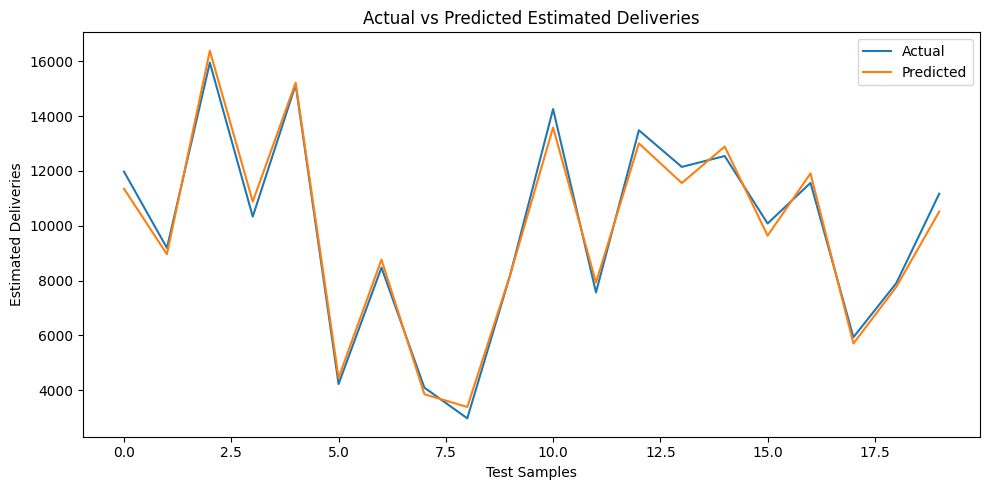

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(y_test.values[:20], label='Actual')
plt.plot(y_pred[:20], label='Predicted')

plt.title('Actual vs Predicted Estimated Deliveries')
plt.xlabel('Test Samples')
plt.ylabel('Estimated Deliveries')

plt.legend()
plt.tight_layout()
plt.show()

**Observation:**

* The predicted values closely follow the actual estimated deliveries.
* Only small differences are observed between the actual and predicted values.
* The Linear Regression model captures the overall trend effectively.
* This is consistent with the high R² score obtained during evaluation.

### 10. 5-Fold Cross Validation

Evaluate the Linear Regression model using 5-fold cross validation and report the R² score for each fold along with the average R² score.

In [21]:
cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring='r2'
)

print("R² score for each fold:", cv_scores)
print(f"Mean R² score: {cv_scores.mean():.4f}")

R² score for each fold: [0.99064898 0.99046596 0.98949291 0.99051101 0.99080587]
Mean R² score: 0.9904


**Observation:**

* The R² scores are consistently high across all five folds.
* The variation between the fold scores is very small.
* The mean R² score is approximately 0.99, indicating excellent model performance.
* The consistent scores suggest that the model generalizes well across different data splits.

### 11. Random Forest Regression with GridSearchCV

Train a Random Forest model, find the best hyperparameters using GridSearchCV, evaluate its performance, and visualize the most important features.

In [22]:
param_grid = {
    'n_estimators': [50,100],
    'max_depth': [5,10,None]
}

In [23]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, None], 'n_estimators': [50, 100]},
             scoring='r2')

In [24]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 50}


In [25]:
best_rf = grid_search.best_estimator_

In [26]:
rf_pred = best_rf.predict(X_test)

In [27]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R² Score: {rf_r2:.4f}")

MAE: 303.86
RMSE: 388.55
R² Score: 0.9902


**Observation:**

* The Random Forest model achieved a high R² score, indicating excellent predictive performance.
* The MAE and RMSE values are low, showing that the prediction errors are small.
* The Random Forest model performs comparably to the Linear Regression model on this dataset.
* Overall, both models provide accurate predictions for estimated deliveries.

#### 11.1 Feature Importance
Visualize the top 10 most important features used by the Random Forest model for prediction.

In [28]:
feature_importance = best_rf.feature_importances_

In [29]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance
})

In [30]:
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

In [31]:
top_features = importance_df.head(10)

In [32]:
print(top_features)

              Feature  Importance
4    Production_Units    0.990055
8      CO2_Saved_tons    0.002163
7            Range_km    0.001221
5       Avg_Price_USD    0.001040
10  Charging_Stations    0.001004
12     Rolling_Mean_3    0.000955
11    Deliveries_Lag1    0.000923
0                Year    0.000888
1               Month    0.000668
3               Model    0.000357


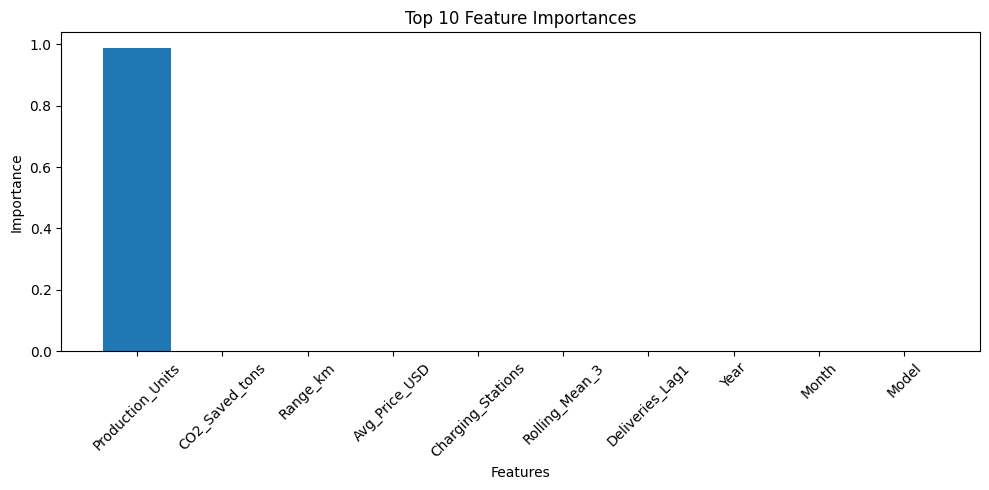

In [33]:
plt.figure(figsize=(10, 5))
plt.bar(top_features['Feature'], top_features['Importance'])

plt.title('Top 10 Feature Importances')
plt.xlabel('Features')
plt.ylabel('Importance')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**

* Production_Units is the most important feature for predicting estimated deliveries.
* The remaining features have comparatively very low importance values.
* The Random Forest model relies primarily on Production_Units for making predictions.
* This agrees with the strong positive correlation observed between Production_Units and Estimated_Deliveries during EDA.

### 12. Augmented Dickey-Fuller (ADF) Test

Perform the Augmented Dickey-Fuller (ADF) test to check whether the Estimated_Deliveries time series is stationary.

In [34]:
adf_result = adfuller(df['Estimated_Deliveries'])
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -53.82661259715622
p-value: 0.0


**Observation:**

* The p-value is less than 0.05, so the Estimated_Deliveries time series is stationary.
* Therefore, we reject the null hypothesis and conclude that the data does not contain a unit root.
* The dataset is suitable for time series analysis without requiring differencing.

### 13. Forecast Table

Create a forecast table showing the first 20 actual and predicted estimated deliveries along with the prediction error percentage.

In [35]:
forecast_df = pd.DataFrame({
    'Actual': y_test.iloc[:20].values,
    'Predicted': rf_pred[:20]
})

In [36]:
forecast_df['Error (%)'] = (
    abs(forecast_df['Actual'] - forecast_df['Predicted'])
    / forecast_df['Actual']
) * 100

In [37]:
forecast_df = forecast_df.round(2)
forecast_df

,Actual,Predicted,Error (%)
0,11974,11244.76,6.09
1,9189,8947.18,2.63
2,15956,16791.60,5.24
3,10336,10896.56,5.42
4,15152,15868.72,4.73
5,4224,4014.38,4.96
6,8475,8863.10,4.58
7,4093,3817.50,6.73
8,2972,3149.94,5.99
9,8208,8202.68,0.06


**Observation:**

* The forecast table compares the actual and predicted estimated deliveries for the first 20 test records.
* The prediction error percentages are generally low, indicating that the Random Forest model provides accurate predictions.
* Lower error percentages show that the predicted values are close to the actual deliveries.

### 14. Model Comparison

Compare the performance of the Linear Regression and Random Forest models using MAE, RMSE, and R² score.

In [38]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [round(mae, 2), round(rf_mae, 2)],
    'RMSE': [round(rmse, 2), round(rf_rmse, 2)],
    'R² Score': [round(r2, 4), round(rf_r2, 4)]
})

comparison_df

,Model,MAE,RMSE,R² Score
0,Linear Regression,310.33,375.56,0.9908
1,Random Forest,303.86,388.55,0.9902


**Observation:**

* Both models achieved excellent predictive performance with R² scores close to 1.
* Random Forest produced a slightly lower MAE, while Linear Regression achieved a lower RMSE and a marginally higher R² score.
* Overall, both models performed very well, with only minor differences in prediction accuracy.